In [1]:
import os
import sys
from dotenv import find_dotenv
sys.path.append(os.path.dirname(find_dotenv()))
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import astropy.units as u
import astropy.constants as const
import arby
import tqdm
import dill as pickle
from sklearn.gaussian_process.kernels import Matern
from astropy.timeseries import LombScargle

import isidora.waveform
import isidora.plotting
import isidora.training

/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


# Set up covariance and mock data

Only h+ waveform on one astrometric axis (assume all other extrinsic parameters set so that this is the case).

Covariance is uniform diagonal + linear kernel (which is non-stationary), tuned so that SNR calculated using diagonal portion ~ 1-5 (?)

In [2]:
with open('data/training_set_full_tile.pkl', 'rb') as f:
    full_tile = pickle.load(f)
    
physical_time = full_tile.physical_time
print(len(physical_time))

61362


In [3]:
# Downsample the time by 6 by taking every 6th time point.
downsample_mask = np.zeros(len(physical_time), dtype=bool)

TIME_DOWNSAMPLE_FACTOR = 6
DEBUG_WHITE_NOISE_ONLY = False

downsample_mask[::TIME_DOWNSAMPLE_FACTOR] = True

print(np.sum(downsample_mask) / len(downsample_mask))

physical_time = physical_time[downsample_mask]
print(len(physical_time))

0.16666666666666666
10227


In [4]:
# covar_kernel = DotProduct(sigma_0=0)
matern_length_scale = 90 * u.day
matern_length_scale_s = (matern_length_scale).to(u.s).value

covar_kernel = Matern(length_scale=matern_length_scale_s, nu=1.5)

In [5]:
# def correlation_from_covariance(covariance):
#     v = np.sqrt(np.diag(covariance))
#     outer_v = np.outer(v, v)
#     correlation = covariance / outer_v
#     correlation[covariance == 0] = 0
#     return correlation

generating_time = physical_time[:, np.newaxis].to(u.s).value
# generating_time -= generating_time.mean()

#corr_matrix = correlation_from_covariance(covar_kernel(generating_time))

corr_matrix = np.zeros((len(generating_time), len(generating_time)), dtype=np.float64)
for i, t in enumerate(np.squeeze(generating_time)):
    corr_matrix[i] = np.squeeze(covar_kernel(X=generating_time, Y=np.ones((1, 1)) * t))

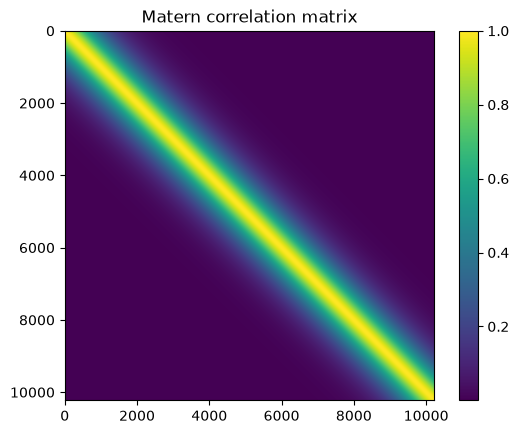

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
plt.imshow(corr_matrix[:, :])
# plt.imshow(covar_kernel(generating_time))
plt.colorbar()
plt.title('Matern correlation matrix')
plt.show()
print(np.diag(corr_matrix)[:10])

Text(0, 0.5, 'Correlation of cross-diagonal')

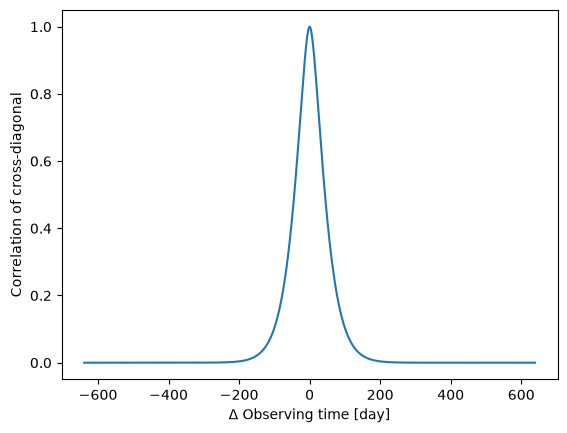

In [7]:
plt.plot(physical_time.to(u.day).value - np.mean(physical_time.to(u.day).value), np.diag(np.fliplr(corr_matrix)))
plt.xlabel(r'$\Delta$ Observing time [day]')
plt.ylabel('Correlation of cross-diagonal')

In [8]:
# Add in diagonal noise
white_dva_scaling_fac = 1e2 # white noise is stronger than DVA 'diagonal' by this factor

cov_matrix = np.diag(np.ones(len(corr_matrix)))
if not DEBUG_WHITE_NOISE_ONLY:
    cov_matrix += (corr_matrix / white_dva_scaling_fac)

# Turn into white noise
# cov_matrix = np.diag(np.diag(cov_matrix))

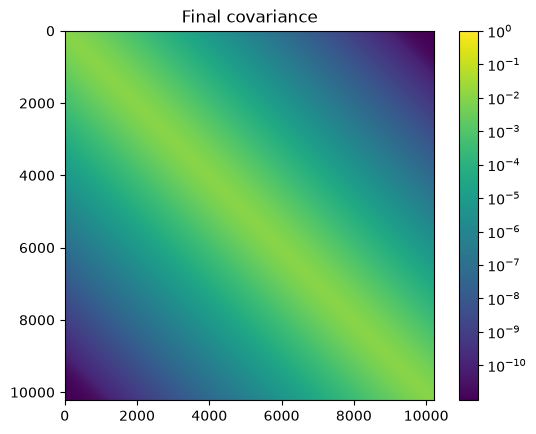

In [9]:
plt.imshow(cov_matrix[:, :], norm=colors.SymLogNorm(linthresh=1e-10))
# plt.imshow(covar_kernel(generating_time))
plt.colorbar()
plt.title('Final covariance')
plt.show()

In [10]:
SUBTILE_ROOT_PATH = Path('data/split-test')

with open(SUBTILE_ROOT_PATH / 'subtile_splits.pkl', 'rb') as f:
    subtile_dict, subtile_param_ind_dict = pickle.load(f)
with open(SUBTILE_ROOT_PATH / 'subtile_rb_dict.pkl', 'rb') as f:
    subtile_rb_dict = pickle.load(f)

In [11]:
freq_splits = np.unique(sum([[t[0].to(u.Hz).value, t[1].to(u.Hz).value] for t in subtile_dict.keys()], []))
freq_splits = u.Quantity(freq_splits, unit=u.Hz)
print(freq_splits)

[1.00000000e-08 1.04290947e-06 2.07011227e-06 3.09731506e-06
 4.12451785e-06 5.15172064e-06 6.17321675e-06] Hz


In [12]:
injection_params = {'q': 1, 'init_phi': np.pi, 
                    'initial_freq': freq_splits[1],
                    'Mc': 3e7 * u.Msun}

# For the purposes of amplitude, assume luminosity distance of 10 Mpc.
# From this, our amplitude is determined as:
# normalizing_dist = isidora.waveform.mass_strain_freq_to_dist_0pn(injection_params['initial_freq'], injection_params['Mc'], 1)
# print(normalizing_dist.to(u.Mpc))

# distance_amp_scaling_factor = normalizing_dist / (10 * u.Mpc)
# print(distance_amp_scaling_factor)

distance_amp_scaling_factor = 1

100%|██████████| 2550/2550 [00:07<00:00, 339.15it/s]


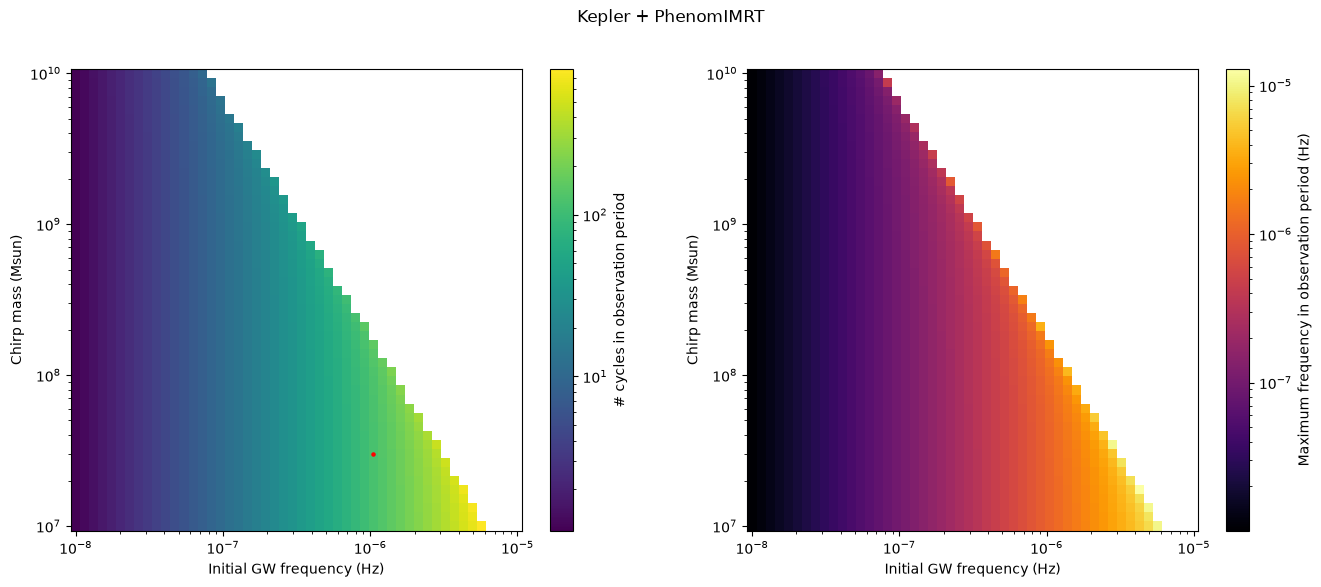

In [13]:
GRID_PARAMS = {
    'freq_limits': (1e-8 * u.Hz, 1e-5 * u.Hz),
    'Mc_limits': (1e7 * u.Msun, 1e10 * u.Msun),
    'n_freq_grid': 1000,
    'n_Mc_grid': 20,
    'freq_logspacing': False,
    'Mc_logspacing': True,
}

_, axes = isidora.plotting.plot_max_freq_and_n_cycles('Kepler + PhenomIMRT', {'q':1 , 'init_phi': 0}, full_tile.phase_func, full_tile.freq_func,
                                            obs_time_max=0, obs_cadence=0,
                                            explicit_obs_time=physical_time[-2:],
                                            freq_limits=GRID_PARAMS['freq_limits'],
                                            Mc_limits=GRID_PARAMS['Mc_limits'],
                                            n_freq_grid=50, n_Mc_grid=51,
                                            skip_gen_errors=True,
                                            progress_bar=True)
cycle_ax = axes[0]
cycle_ax.scatter(injection_params['initial_freq'], injection_params['Mc'], color='red', s=5)


In [14]:
target_snr = 3.5
n_stars = 100

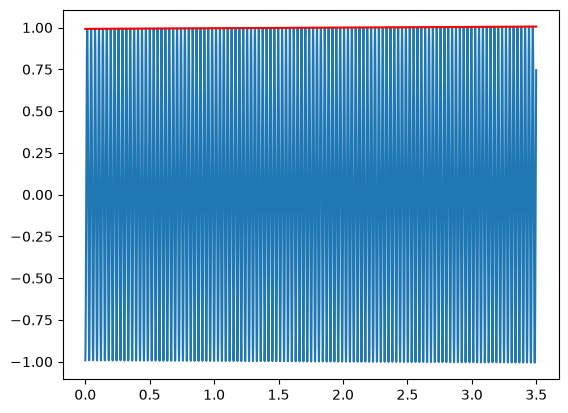

Waveform amplitude scaling factor: 4.950e-03


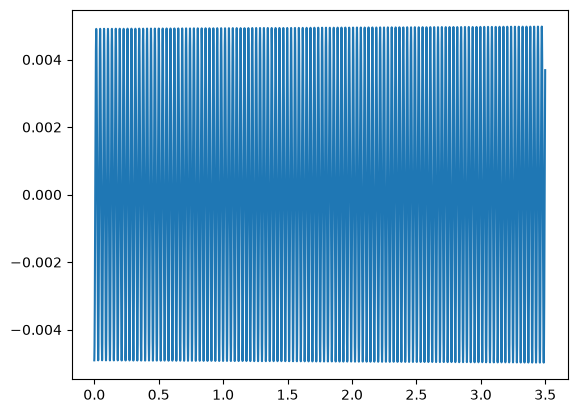

In [15]:
injected_wf = full_tile.generate_full_waveform(injection_params, skip_het=True)[downsample_mask]
plt.plot(physical_time.to(u.yr).value, np.real(injected_wf))
plt.plot(physical_time.to(u.yr).value, np.abs(injected_wf), color='red')
plt.show()

avg_envelope = np.mean(np.abs(injected_wf))

injected_wf = np.real(injected_wf)
# Scale so SNR = target, using RMS as proxy for signal strength.
wf_amp_factor = target_snr * ((avg_envelope / cov_matrix[0, 0]) / np.sqrt(2) * np.sqrt(len(injected_wf) * n_stars))**-1

print(f'Waveform amplitude scaling factor: {wf_amp_factor:.3e}')

# Additional kludge factor for double-checking the ROQ likelihood error scaling when we downsample time further:
# I think b/c the # of off-diagonal entries from the covariance goes like 

injected_wf *= (wf_amp_factor * distance_amp_scaling_factor)

cov_matrix *= (distance_amp_scaling_factor**2)

injection_params['wf_amp_factor'] = wf_amp_factor * distance_amp_scaling_factor

plt.plot(physical_time.to(u.yr).value, injected_wf)

# shape (n_stars, T)
injected_wf = np.repeat(injected_wf[np.newaxis, :], n_stars, axis=0)

In [16]:
with open('data/toy-mcmc/injected_wf_params.pkl', 'wb') as f:
    pickle.dump(injection_params, f)

np.save('data/toy-mcmc/covariance.npy', cov_matrix)
np.save('data/toy-mcmc/injected_wf.npy', injected_wf)

np.savez('data/toy-mcmc/downsampled_time.npz', downsampled_time=physical_time, mask=downsample_mask)

# Script blob

In [17]:
from jax import config as jax_config
jax_config.update("jax_enable_x64", True)
import jax
from jax.sharding import PartitionSpec as P, NamedSharding
import jax.numpy as jnp
from jaxmg import potri
import numpy as np


RANDOM_SEED = 1289347398 #+ 120 + 7

covar = jnp.load('data/toy-mcmc/covariance.npy')
print(covar.shape, covar.dtype)
print(f'Covar condition number: {jnp.linalg.cond(covar)}')
injected_wf = jnp.load('data/toy-mcmc/injected_wf.npy')

prng_key = jax.random.key(RANDOM_SEED)

noise_realization = jax.random.multivariate_normal(prng_key, mean=jnp.zeros(covar.shape[0]), cov=covar, shape=(n_stars,))
print(injected_wf.shape, noise_realization.shape)
np.save('data/toy-mcmc/mock_data.npy', injected_wf + noise_realization)

# Invert covariance.
mesh = jax.make_mesh((1,), ('x',))
pspec = P("x", None)
covar = jax.device_put(covar, NamedSharding(mesh, pspec))
covar, status = potri(covar, 487, mesh, pspec, return_status=True)
print(status)
np.save('data/toy-mcmc/inverse_covariance.npy', covar)

(10227, 10227) float64
Covar condition number: 17.19209432564847
(100, 10227) (100, 10227)
0


# Look at mock data and invcov

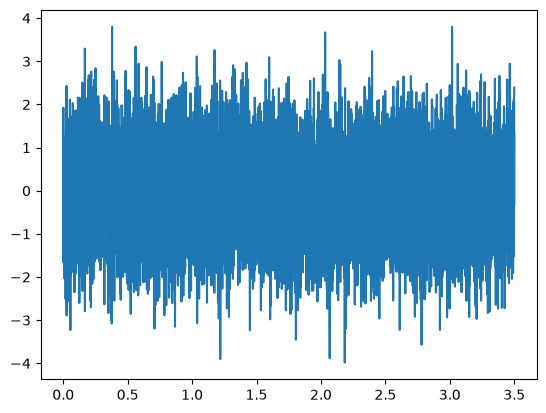

In [18]:
# This is expensive, so do it in JAX instead if GPU memory allows

mock_data = np.load('data/toy-mcmc/mock_data.npy')

plt.plot(physical_time.to(u.yr).value, mock_data[0])

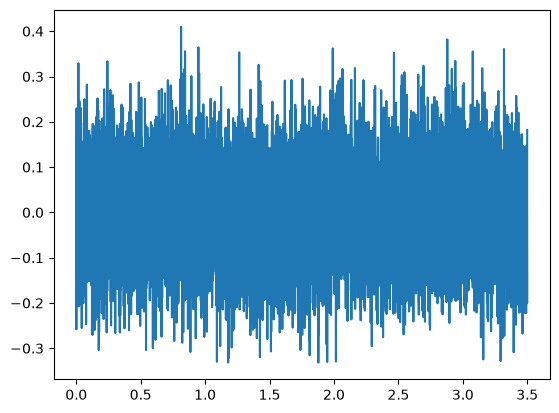

In [19]:
plt.plot(physical_time.to(u.yr).value, np.mean(mock_data, axis=0))

In [20]:
# for i in range(n_stars):
#     ls_freq, ls_power = LombScargle(physical_time, mock_data[i]).autopower()
#     plt.loglog(ls_freq.to(u.Hz).value, ls_power, alpha=1 / n_stars)

# plt.axvline(injection_params['initial_freq'].to(u.Hz).value, color='black', ls='--', label='Injected GW', alpha=0.5)
# plt.axvline(1 / matern_length_scale_s, color='red', ls='--', label='1 / Matern time scale')
# plt.xlabel('Frequency [Hz]')
# plt.ylabel('LS autopower')
# plt.legend()
# plt.title(f'SNR = {target_snr}, 3/2 Matern covariance, {matern_length_scale} smoothing scale, {white_dva_scaling_fac}x smaller than white noise')

Text(0.5, 1.0, 'SNR = 3.5, 3/2 Matern covariance, 90.0 d smoothing scale, 100.0x smaller than white noise')

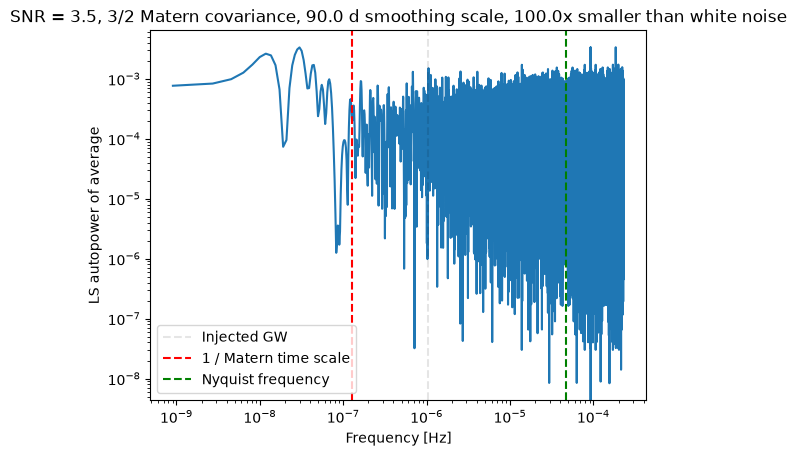

In [21]:
ls_freq, mean_power = LombScargle(physical_time, np.mean(mock_data, axis=0)).autopower()
plt.loglog(ls_freq.to(u.Hz).value, mean_power)

plt.axvline(injection_params['initial_freq'].to(u.Hz).value, color='black', ls='--', label='Injected GW', alpha=0.1)
plt.axvline(1 / matern_length_scale_s, color='red', ls='--', label='1 / Matern time scale')
plt.axvline(0.5 / (physical_time[1] - physical_time[0]).to(u.s).value, color='green', ls='--', label='Nyquist frequency')
plt.xlabel('Frequency [Hz]')
plt.ylabel('LS autopower of average')
plt.legend()
plt.title(f'SNR = {target_snr}, 3/2 Matern covariance, {matern_length_scale} smoothing scale, {white_dva_scaling_fac}x smaller than white noise')

In [22]:
with open('data/toy-mcmc/mean-periodogram.pickle', 'wb') as f:
    pickle.dump((ls_freq, mean_power), f)

In [23]:
invcov = np.load('data/toy-mcmc/inverse_covariance.npy')

In [24]:
full_optimal_snr = np.sum(np.einsum('ai,ij,aj->a', injected_wf, invcov, injected_wf)**0.5 / np.sqrt(n_stars))
print(full_optimal_snr)

3.53379908810577


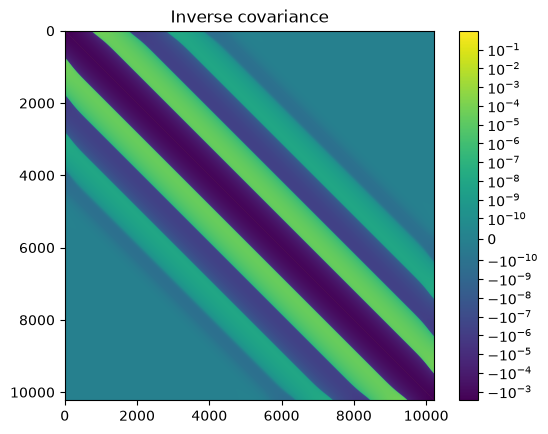

In [25]:
plt.imshow(invcov, norm=colors.SymLogNorm(linthresh=1e-10))
plt.title('Inverse covariance')
plt.colorbar()

Text(0, 0.5, 'Inverse covariance cross-diagonal')

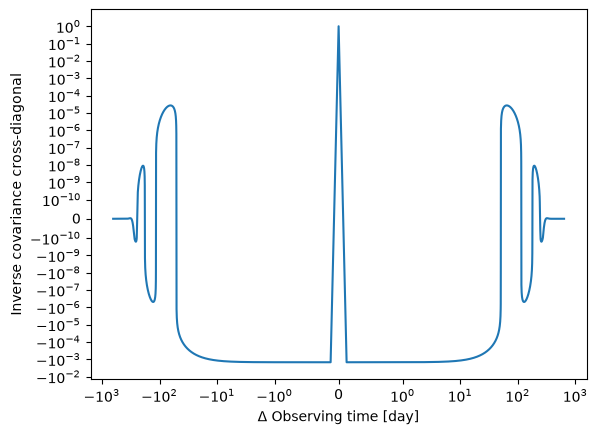

In [26]:
plt.plot(physical_time.to(u.day).value - np.mean(physical_time.to(u.day).value), np.diag(np.fliplr(invcov)))
plt.yscale('symlog', linthresh=1e-10)
plt.xscale('symlog', linthresh=1)
plt.xlabel(r'$\Delta$ Observing time [day]')
plt.ylabel('Inverse covariance cross-diagonal')

In [27]:
np.diag(invcov)

array([0.99705877, 0.99706742, 0.99707604, ..., 0.99707604, 0.99706742,
       0.99705877], shape=(10227,))